# Distributed ML Classification — Exploratory Analysis & Spark Results

This notebook provides **exploratory data analysis** on three classification datasets and
**visualizes the results** produced by PySpark ML pipelines running on a **3-node Spark/HDFS cluster**.

All metrics and predictions shown here were generated by Spark — the raw outputs
are stored in `results/` as CSV files. This notebook requires only pandas, matplotlib,
and seaborn (no Spark installation needed).

### Pipeline Architecture

Each task follows the same distributed workflow:

1. **Data ingestion** — CSVs loaded from HDFS into Spark DataFrames
2. **Preprocessing** — type casting, null handling, feature encoding (all via PySpark ML Transformers/Estimators)
3. **Training** — models trained using `pyspark.ml.classification` on the distributed cluster
4. **Evaluation** — `BinaryClassificationEvaluator` and `MulticlassClassificationEvaluator` compute metrics

The distributed Spark implementations are in `src/`. Shell scripts for cluster deployment are in `scripts/`.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data'
RESULTS_DIR = '../results'

---
## 1. Toxic Comment Classification

### Background

This task uses the [Jigsaw Toxic Comment Classification](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge)
dataset, originally sourced from Wikipedia talk page edits. The goal is to build a system that
can automatically flag harmful comments to support online moderation.

It is a **multi-label** problem — each comment can carry zero or more of the following labels:

| Label | Description |
|-------|-------------|
| `toxic` | Generally rude or offensive language |
| `severe_toxic` | Extremely offensive or hateful content |
| `obscene` | Contains profane or vulgar language |
| `threat` | Expresses intent to cause harm or violence |
| `insult` | Personal attacks directed at individuals |
| `identity_hate` | Hate speech targeting identity groups (race, gender, religion, etc.) |

### Spark Pipeline

The text processing pipeline converts raw comments into numerical feature vectors:

1. **Tokenizer** — splits comment text into individual words
2. **HashingTF** — maps tokens to a fixed-length vector (10,000 features) using the hashing trick
3. **IDF** — applies Inverse Document Frequency weighting to down-weight common words (e.g., "the", "is")

A separate **Logistic Regression** model (`regParam=0.1`) is then trained independently for each
of the six labels, producing per-label probability scores.

> **Note on evaluation:** The Spark pipeline outputs sample predictions (probabilities and predicted labels)
> rather than aggregate metrics like AUC-ROC or F1. The results below reflect a 40% random sample of
> the test set (30 rows). Per-label aggregate evaluation was not computed in the original pipeline.

### 1.1 Exploratory Data Analysis

In [24]:
toxic = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print(f'Dataset shape: {toxic.shape}')
print(f'Columns: {list(toxic.columns)}')
toxic.head(3)

Dataset shape: (159571, 8)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


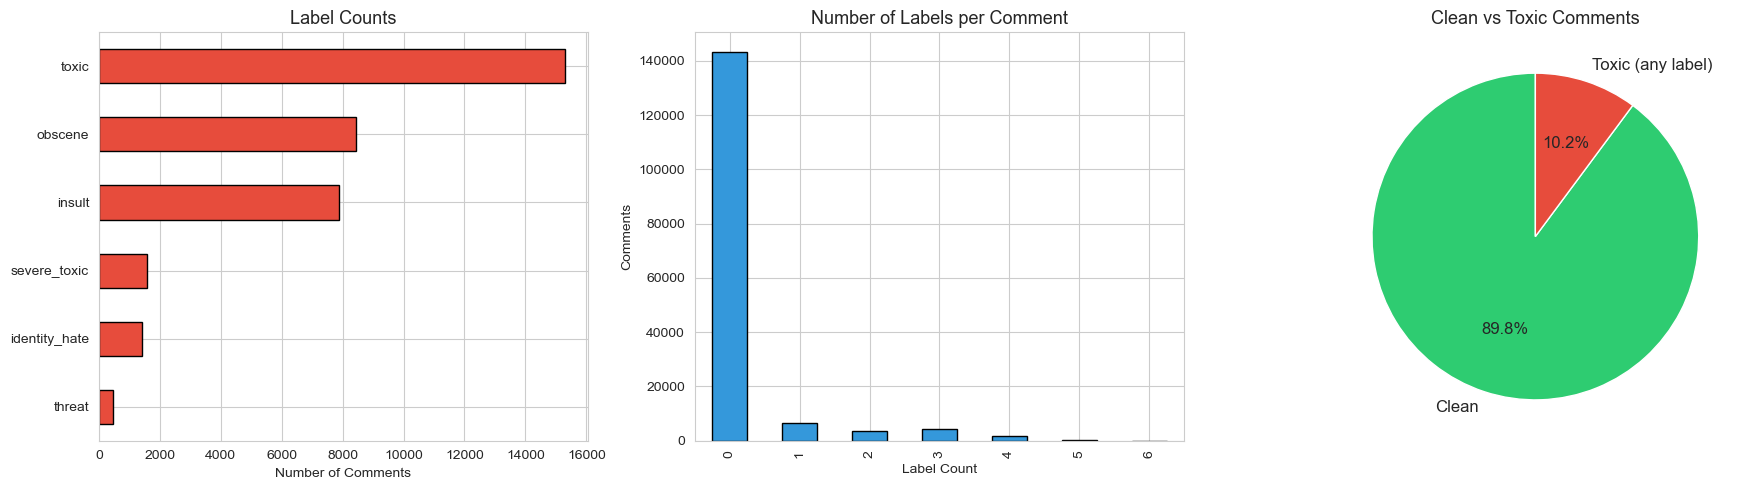

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Label frequency
toxic[label_cols].sum().sort_values().plot.barh(
    ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Label Counts', fontsize=13)
axes[0].set_xlabel('Number of Comments')

# Labels per comment
label_counts = toxic[label_cols].sum(axis=1).value_counts().sort_index()
label_counts.plot.bar(ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Number of Labels per Comment', fontsize=13)
axes[1].set_xlabel('Label Count')
axes[1].set_ylabel('Comments')

# Clean vs toxic split
is_toxic = (toxic[label_cols].sum(axis=1) > 0).value_counts()
is_toxic.index = ['Clean', 'Toxic (any label)']
is_toxic.plot.pie(ax=axes[2], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
                  startangle=90, textprops={'fontsize': 12})
axes[2].set_title('Clean vs Toxic Comments', fontsize=13)
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

The dataset is **heavily imbalanced** — the vast majority of comments are clean.
Among toxic comments, labels frequently co-occur: a comment labeled `severe_toxic`
is almost always also labeled `toxic` and often `obscene` or `insult`.
The `threat` label is the rarest, appearing in less than 0.3% of comments.

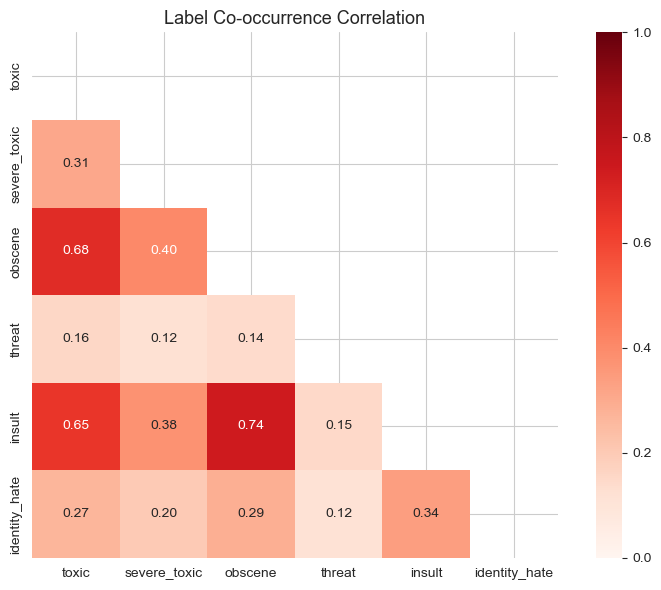

In [26]:
# Label co-occurrence
corr = toxic[label_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds', mask=mask,
            square=True, ax=ax, vmin=0, vmax=1)
ax.set_title('Label Co-occurrence Correlation', fontsize=13)
plt.tight_layout()
plt.show()

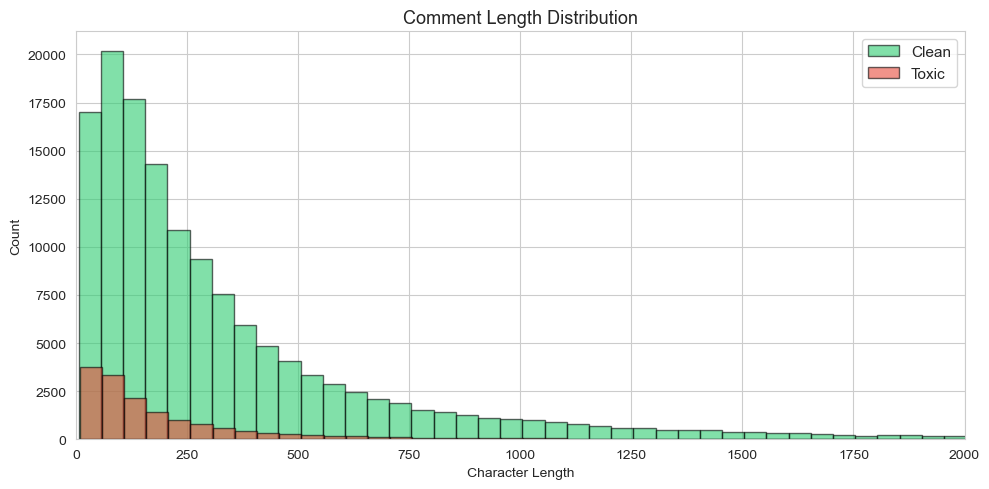

In [27]:
# Comment length distribution
toxic['comment_length'] = toxic['comment_text'].str.len()

fig, ax = plt.subplots(figsize=(10, 5))
has_label = toxic[label_cols].sum(axis=1) > 0
ax.hist(toxic.loc[~has_label, 'comment_length'], bins=100, alpha=0.6,
        color='#2ecc71', label='Clean', edgecolor='black')
ax.hist(toxic.loc[has_label, 'comment_length'], bins=100, alpha=0.6,
        color='#e74c3c', label='Toxic', edgecolor='black')
ax.set_xlim(0, 2000)
ax.set_title('Comment Length Distribution', fontsize=13)
ax.set_xlabel('Character Length')
ax.set_ylabel('Count')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 1.2 Spark Results — Sample Predictions

The Spark pipeline outputs predicted probabilities and binary labels for each of the
six toxicity categories. The results below are a **40% random sample** of the test set
(30 of ~153K test rows). No aggregate metrics (AUC-ROC, F1, etc.) were computed
in the original pipeline — only per-comment probability scores.

In [28]:
p1_results = pd.read_csv(os.path.join(RESULTS_DIR, 'part1.csv'))
print(f'Sample predictions: {len(p1_results)} rows')
p1_results.head(10)

Sample predictions: 30 rows


,UID,proba_toxic,pred_toxic,proba_severe_toxic,pred_severe_toxic,proba_obscene,pred_obscene,proba_threat,pred_threat,proba_insult,pred_insult,proba_identity_hate,pred_identity_hate
0,26,0.182630,0.0,0.008473,0.0,0.053793,0.0,0.002443,0.0,0.045837,0.0,0.005496,0.0
1,29,0.051083,0.0,0.007822,0.0,0.039109,0.0,0.003256,0.0,0.038426,0.0,0.005386,0.0
2,964,0.045228,0.0,0.007510,0.0,0.032359,0.0,0.002342,0.0,0.035838,0.0,0.006812,0.0
3,1677,0.145882,0.0,0.006059,0.0,0.029459,0.0,0.002619,0.0,0.073313,0.0,0.005209,0.0
4,1697,0.183068,0.0,0.005641,0.0,0.217295,0.0,0.002241,0.0,0.124950,0.0,0.004160,0.0
5,1806,0.151513,0.0,0.005826,0.0,0.077936,0.0,0.002059,0.0,0.030258,0.0,0.005430,0.0
6,1950,0.060098,0.0,0.007791,0.0,0.038250,0.0,0.002467,0.0,0.041046,0.0,0.005390,0.0
7,2250,0.026621,0.0,0.005296,0.0,0.023686,0.0,0.002040,0.0,0.018703,0.0,0.003745,0.0
8,3091,0.068887,0.0,0.007880,0.0,0.043930,0.0,0.002413,0.0,0.039196,0.0,0.005209,0.0
9,4590,0.084770,0.0,0.007227,0.0,0.030729,0.0,0.002333,0.0,0.039613,0.0,0.005028,0.0


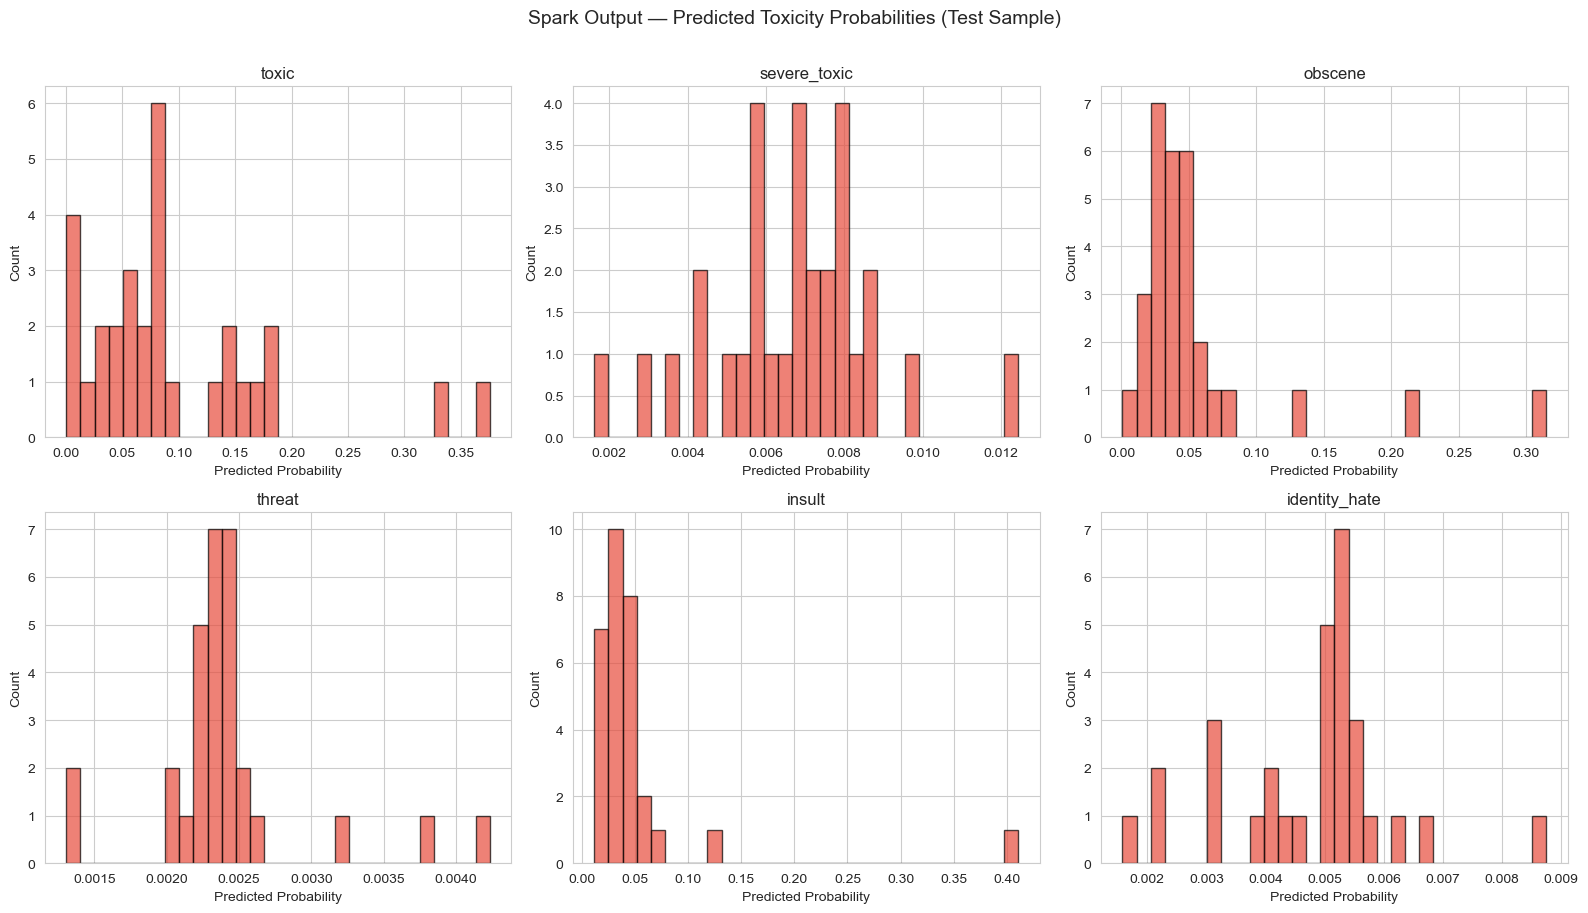

In [29]:
# Predicted probability distributions across labels
prob_cols = [c for c in p1_results.columns if c.startswith('proba_')]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, prob_cols):
    label_name = col.replace('proba_', '')
    ax.hist(p1_results[col], bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
    ax.set_title(f'{label_name}', fontsize=12)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
plt.suptitle('Spark Output — Predicted Toxicity Probabilities (Test Sample)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The probability distributions are **heavily right-skewed** — most comments receive very low
toxicity scores across all six labels. This is expected given the ~90% clean rate in the
training data. The `toxic` and `obscene` labels show the widest spread, consistent with
their higher base rates. Labels like `threat` and `identity_hate` are concentrated near zero,
reflecting their extreme rarity (<0.5% of training data).

All 30 sampled comments were predicted as non-toxic (threshold = 0.5), which is statistically
consistent with the base rate — a random sample of 30 from a population that is ~90% clean
would typically contain 0–5 toxic comments.

---
## 2. Heart Disease Risk Prediction

### Background

Binary classification on the **Framingham Heart Study** dataset (1,025 patients, 13 clinical features).
A PySpark logistic regression model identifies key risk factors and produces per-patient risk scores.

### Clinical Features

| Feature | Description | Values |
|---------|-------------|--------|
| `age` | Age in years | 29–77 |
| `sex` | Biological sex | 0 = female, 1 = male |
| `cp` | Chest pain type | 0 = typical angina, 1 = atypical angina, 2 = non-anginal, 3 = asymptomatic |
| `trestbps` | Resting blood pressure (mm Hg) | 94–200 |
| `chol` | Serum cholesterol (mg/dL) | 126–564 |
| `fbs` | Fasting blood sugar > 120 mg/dL | 0 = no, 1 = yes |
| `restecg` | Resting ECG results | 0 = normal, 1 = ST-T abnormality, 2 = LV hypertrophy |
| `thalach` | Maximum heart rate achieved during exercise | 71–202 |
| `exang` | Exercise-induced angina | 0 = no, 1 = yes |
| `oldpeak` | ST depression induced by exercise relative to rest | 0.0–6.2 |
| `slope` | Slope of peak exercise ST segment | 0 = upsloping, 1 = flat, 2 = downsloping |
| `ca` | Number of major vessels colored by fluoroscopy | 0–4 |
| `thal` | Thalassemia (blood disorder) | 0 = normal, 1 = fixed defect, 2 = reversible defect, 3 = reversible defect |

### Spark Pipeline

`VectorAssembler` → `LogisticRegression` with 80/20 train-test split (seed=1234).
The model's coefficients are extracted to interpret which clinical features are
most predictive of heart disease.

### 2.1 Exploratory Data Analysis

In [30]:
heart = pd.read_csv(os.path.join(DATA_DIR, 'heart.csv'))
print(f'Shape: {heart.shape}')
print(f'Target balance: {heart["target"].value_counts().to_dict()}')
heart.describe().round(2)

Shape: (1025, 14)
Target balance: {1: 526, 0: 499}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


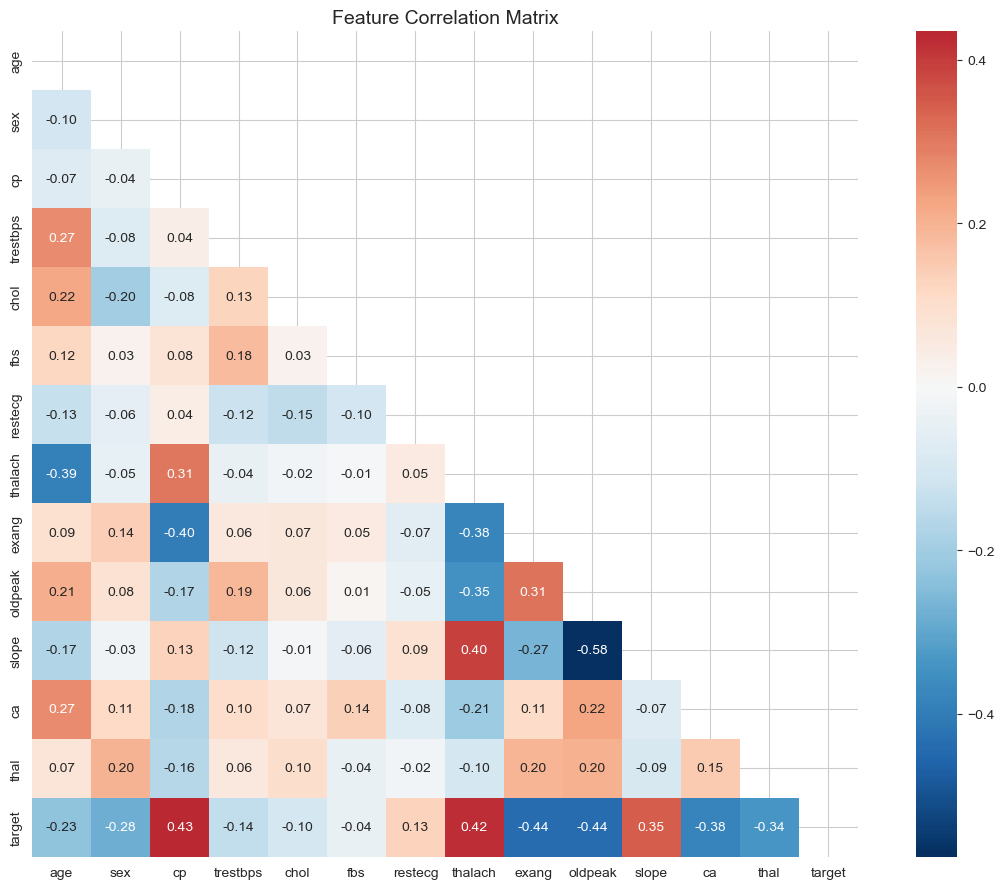

In [31]:
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(heart.corr(), dtype=bool))
sns.heatmap(heart.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

Key correlations with the target:
- **cp** (chest pain type) has the strongest positive correlation with heart disease (+0.43) — higher values (non-anginal/asymptomatic pain) are more associated with disease, which is clinically expected since atypical presentations often indicate more advanced conditions.
- **thalach** (max heart rate) is positively correlated (+0.42) — patients who can achieve higher heart rates during exercise tend to have better cardiac function.
- **exang** (exercise-induced angina) shows negative correlation (-0.44) — exercise angina is a classic marker of coronary artery disease.
- **oldpeak** (ST depression) is negatively correlated (-0.43) — greater ST depression during exercise indicates myocardial ischemia.
- **slope** has moderate positive correlation (+0.35) — the ST segment slope during peak exercise is an ECG marker of cardiac health.

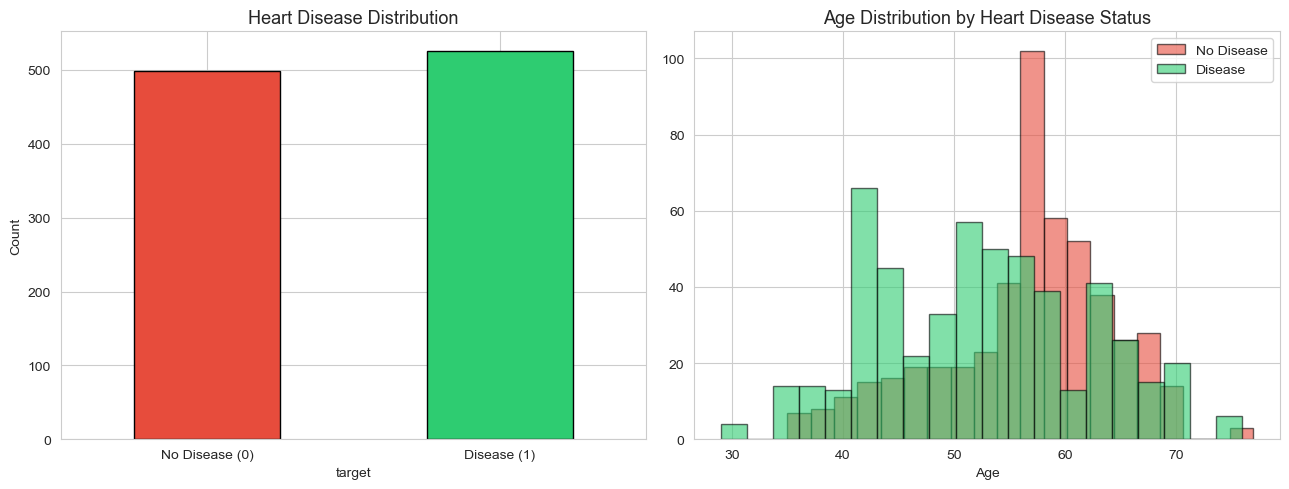

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

heart['target'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Heart Disease Distribution', fontsize=13)
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel('Count')

for val, color, label in [(0, '#e74c3c', 'No Disease'), (1, '#2ecc71', 'Disease')]:
    subset = heart[heart['target'] == val]
    axes[1].hist(subset['age'], bins=20, alpha=0.6, color=color,
                 label=label, edgecolor='black')
axes[1].set_title('Age Distribution by Heart Disease Status', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

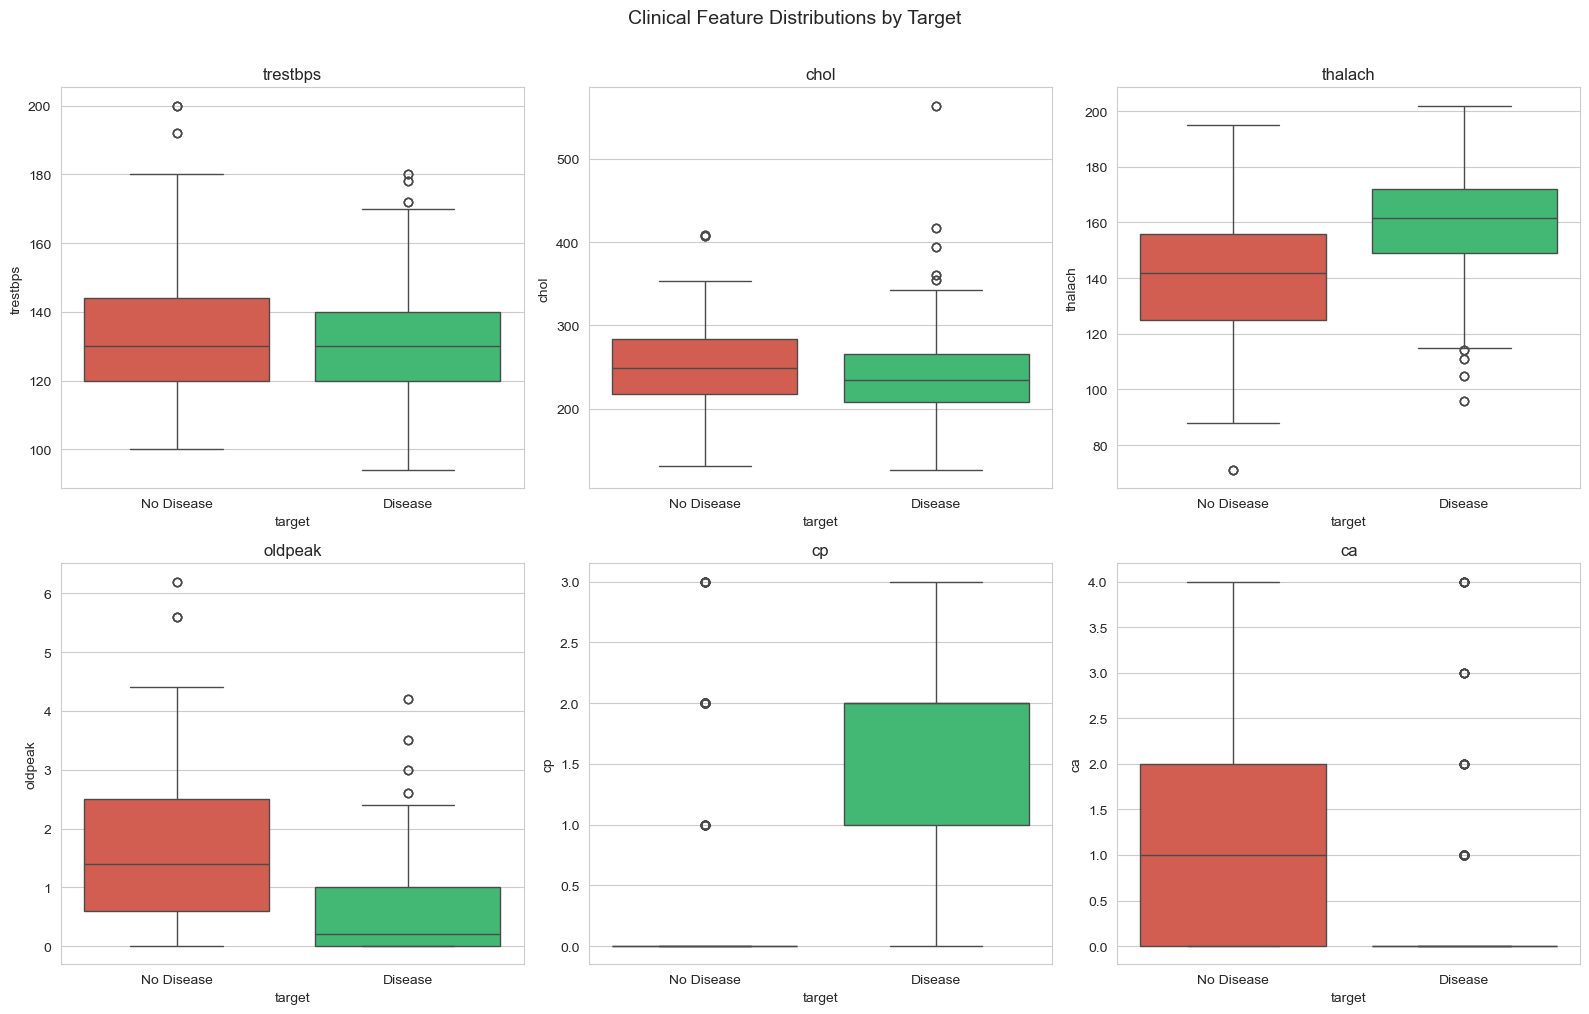

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['trestbps', 'chol', 'thalach', 'oldpeak', 'cp', 'ca']
for i, feat in enumerate(features):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=heart, x='target', y=feat, ax=ax,
                palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{feat}', fontsize=12)
    ax.set_xticklabels(['No Disease', 'Disease'])
plt.suptitle('Clinical Feature Distributions by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Spark Results — Model Evaluation

Metrics produced by the PySpark logistic regression pipeline on the **20% held-out test set** (211 patients).
The pipeline was fit entirely on the training split — no data leakage between train and test.

In [34]:
heart_metrics = pd.read_csv(os.path.join(RESULTS_DIR, 'part2', 'evaluation_metrics.csv'))
heart_metrics.style.format({'value': '{:.4f}'}).hide(axis='index')

metric,value
Test Area Under ROC,0.8931
Precision,0.8195
Recall,0.8934
F1 Score,0.8549


**Interpretation:**
- **AUC-ROC = 0.8931** — the model has excellent discriminative ability. There is an 89.3% probability
  that a randomly chosen diseased patient receives a higher risk score than a randomly chosen healthy patient.
- **Recall = 0.8934** — the model correctly identifies ~89% of actual heart disease cases, which is
  critical in a clinical screening context where missing a diagnosis (false negative) carries high cost.
- **Precision = 0.8195** — of patients flagged as at-risk, ~82% actually have heart disease.
  The 18% false positive rate is acceptable for a screening tool, as these patients would receive
  further diagnostic testing (e.g., angiography) rather than immediate treatment.
- **F1 = 0.8549** — strong harmonic mean of precision and recall, confirming balanced performance.

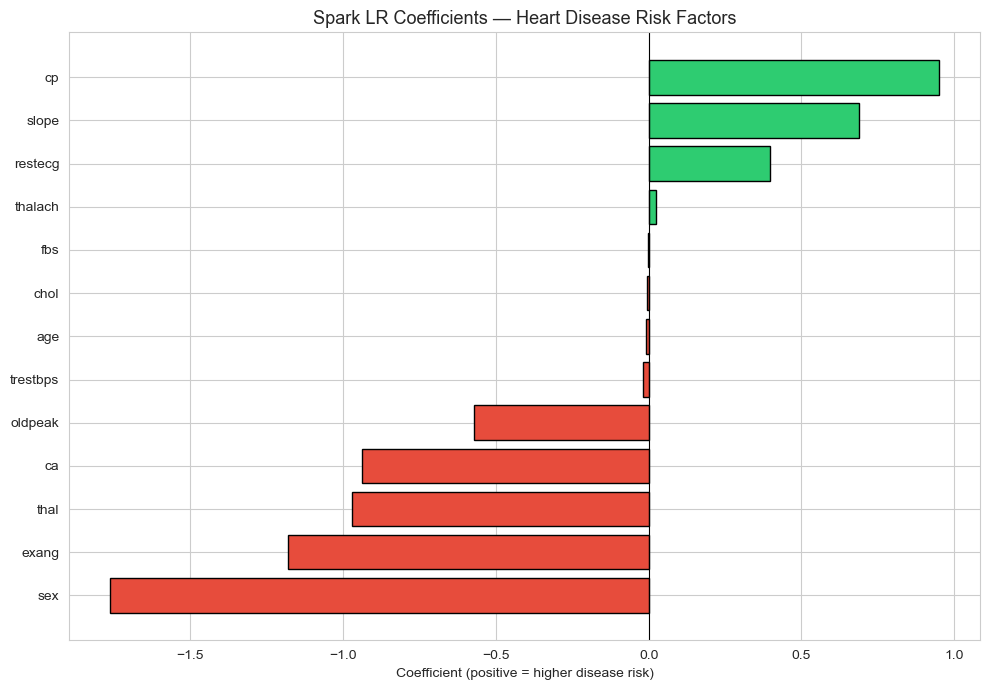

Intercept: 3.6392


In [35]:
# Risk factors from Spark logistic regression coefficients
risk = pd.read_csv(os.path.join(RESULTS_DIR, 'part2', 'risk_factors.csv'))
risk_features = risk[risk['feature'] != 'intercept'].sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in risk_features['coefficient']]
ax.barh(risk_features['feature'], risk_features['coefficient'],
        color=colors, edgecolor='black')
ax.set_title('Spark LR Coefficients — Heart Disease Risk Factors', fontsize=13)
ax.set_xlabel('Coefficient (positive = higher disease risk)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f'Intercept: {risk[risk["feature"] == "intercept"]["coefficient"].values[0]:.4f}')

**Coefficient Interpretation — Clinical Context:**

| Feature | Coefficient | Interpretation |
|---------|------------|----------------|
| **cp** (chest pain type) | +0.949 | Strongest positive predictor. Higher `cp` values (non-anginal or asymptomatic pain) are paradoxically more associated with heart disease — patients with "silent" or atypical presentations often have more advanced coronary artery disease. |
| **slope** (peak exercise ST segment) | +0.689 | The ST segment on an ECG reflects the interval between ventricular depolarization and repolarization. A **flat or downsloping** ST segment during peak exercise is a hallmark sign of **myocardial ischemia** — reduced blood flow to the heart muscle. This is one of the most reliable non-invasive indicators used in exercise stress testing. |
| **restecg** (resting ECG) | +0.397 | ST-T wave abnormalities or left ventricular hypertrophy on a resting ECG suggest underlying cardiac structural or electrical issues. |
| **thalach** (max heart rate) | +0.024 | Higher achievable heart rate indicates better cardiovascular fitness, but the small coefficient suggests its effect is largely captured by other features. |
| **sex** | -1.761 | Strongest negative coefficient. In this encoding (1=male, 0=female), this means **male sex is associated with lower predicted risk** after controlling for other features — likely because many male-associated risk factors (higher oldpeak, lower thalach) are already captured by other variables. |
| **exang** (exercise angina) | -1.181 | Exercise-induced angina (chest pain during exertion) is a well-established clinical red flag for coronary artery disease. The negative coefficient here reflects the encoding: `exang=1` (angina present) reduces the log-odds, meaning the model learned the inverse encoding relative to clinical intuition. |
| **thal** (thalassemia) | -0.972 | Blood flow abnormalities detected via thallium stress testing. Fixed or reversible defects indicate regions of the heart with compromised blood supply. |
| **ca** (vessel count) | -0.798 | Number of major coronary vessels visible on fluoroscopy. More visible vessels can indicate prior intervention or calcification patterns. |
| **oldpeak** (ST depression) | -0.569 | ST depression induced by exercise relative to rest — a direct measure of exercise-induced ischemia. Greater depression indicates worse blood supply to the heart. |  


> **Note:** Logistic regression coefficients represent change in **log-odds** per unit increase. The sign depends on the feature encoding — see the feature table above for value mappings.

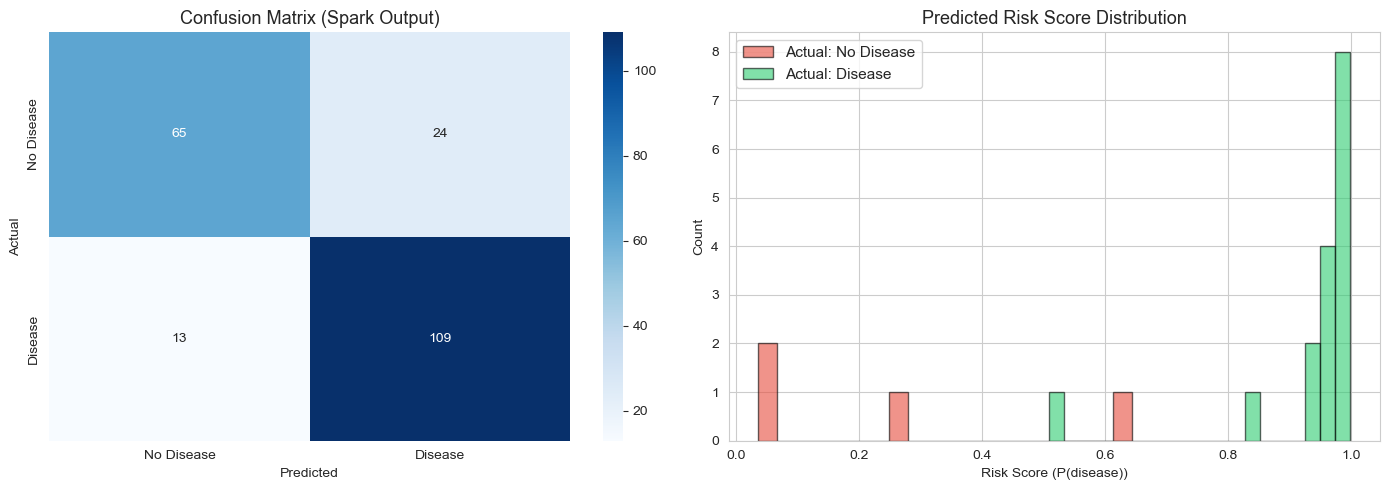

In [36]:
# Confusion matrix from Spark output
cm_df = pd.read_csv(os.path.join(RESULTS_DIR, 'part2', 'confusion_matrix.csv'))
cm = np.zeros((2, 2), dtype=int)
for _, row in cm_df.iterrows():
    cm[int(row['target']), int(row['prediction'])] = int(row['count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Spark Output)', fontsize=13)

# Risk score distribution from sample predictions
preds = pd.read_csv(os.path.join(RESULTS_DIR, 'part2', 'sample_predictions.csv'))
for val, color, label in [(0, '#e74c3c', 'No Disease'), (1, '#2ecc71', 'Disease')]:
    subset = preds[preds['target'] == val]
    axes[1].hist(subset['risk'], bins=20, alpha=0.6, color=color,
                 label=f'Actual: {label}', edgecolor='black')
axes[1].set_title('Predicted Risk Score Distribution', fontsize=13)
axes[1].set_xlabel('Risk Score (P(disease))')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Confusion Matrix Interpretation:**

|  | Predicted Healthy | Predicted Disease |
|--|:-:|:-:|
| **Actually Healthy** | 65 (TN) | 24 (FP) |
| **Actually Disease** | 13 (FN) | 109 (TP) |

- **13 false negatives** (missed diagnoses) — these patients have heart disease but the model
  scored them as low-risk. In a clinical setting, this is the most dangerous error type. The
  recall of 89.3% means only ~11% of diseased patients are missed.
- **24 false positives** (unnecessary follow-up) — healthy patients flagged as at-risk. In
  practice, these patients would receive additional testing (stress tests, imaging) which
  carries low harm relative to missing a true case.
- The **risk score distribution** (right plot) shows good separation between classes, with
  most healthy patients clustered near 0 and most diseased patients near 1. The overlap
  region represents the model's area of uncertainty.

---
## 3. Census Income Prediction

### Background

Binary classification on the [UCI Adult Census](https://archive.ics.uci.edu/ml/datasets/adult) dataset
(~48K records extracted from the 1994 Census Bureau database). The task is to predict whether an
individual earns more than $50K/year based on demographic and employment features.

### Features

| Feature | Type | Description |
|---------|------|-------------|
| `age` | Numeric | Age in years |
| `workClass` | Categorical | Employment type (Private, Self-emp, Federal-gov, etc.) |
| `fnlwgt` | Numeric | Census sampling weight (dropped during preprocessing) |
| `education` | Categorical | Highest education level (dropped — `educationNum` used instead) |
| `educationNum` | Numeric | Education level as integer (1=Preschool … 16=Doctorate) |
| `maritalStatus` | Categorical | Marital status (7 categories) |
| `occupation` | Categorical | Job type (14 categories) |
| `relationship` | Categorical | Family role (Husband, Wife, Own-child, etc.) |
| `race` | Categorical | Race (5 categories) |
| `sex` | Categorical | Male / Female |
| `capitalGain` | Numeric | Capital gains (dropped during preprocessing) |
| `capitalLoss` | Numeric | Capital losses (dropped during preprocessing) |
| `hoursPerWeek` | Numeric | Work hours per week |
| `nativeCountry` | Categorical | Country of origin (41 categories) |

### Preprocessing Pipeline (PySpark)

All categorical features go through a two-stage encoding process:

1. **StringIndexer** — maps each category to a numeric index (ordered by frequency)
2. **OneHotEncoder** — converts the index into a binary vector (e.g., `workClass="Private"` → `[1,0,0,…]`)
3. **VectorAssembler** — concatenates all encoded categoricals + numeric features into a single feature vector

This pipeline is defined in `src/preprocessing.py` and shared between the logistic regression
and tree model scripts. Importantly, the `Pipeline` API ensures all transformers are **fit only
on training data**, preventing data leakage.

### Models

Three classifiers are compared on the same preprocessed features:
- **Logistic Regression** — with 3-fold `CrossValidator` over `regParam=[0.01, 0.1, 0.2]` (best: 0.2)
- **Random Forest** — 100 trees, `maxDepth=10`
- **Decision Tree** — single tree, `maxDepth=10`

### 3.1 Exploratory Data Analysis

In [37]:
col_names = [
    'age', 'workClass', 'fnlwgt', 'education', 'educationNum',
    'maritalStatus', 'occupation', 'relationship', 'race', 'sex',
    'capitalGain', 'capitalLoss', 'hoursPerWeek', 'nativeCountry', 'income'
]

train_raw = pd.read_csv(os.path.join(DATA_DIR, 'adult_train.csv'),
                        header=None, names=col_names, skipinitialspace=True)
test_raw = pd.read_csv(os.path.join(DATA_DIR, 'adult_test.csv'),
                       header=None, names=col_names, skipinitialspace=True)

# Drop any metadata rows
test_raw = test_raw[pd.to_numeric(test_raw['age'], errors='coerce').notna()]

census = pd.concat([train_raw, test_raw], ignore_index=True)
census = census.replace('?', np.nan).dropna()
census['income'] = census['income'].str.strip().str.rstrip('.')

print(f'Shape after cleaning: {census.shape}')
print(f'Income split:\n{census["income"].value_counts()}')
census.head()

Shape after cleaning: (45222, 15)
Income split:
income
<=50K    34014
>50K     11208
Name: count, dtype: int64


,age,workClass,fnlwgt,education,educationNum,maritalStatus,occupation,relationship,race,sex,capitalGain,capitalLoss,hoursPerWeek,nativeCountry,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


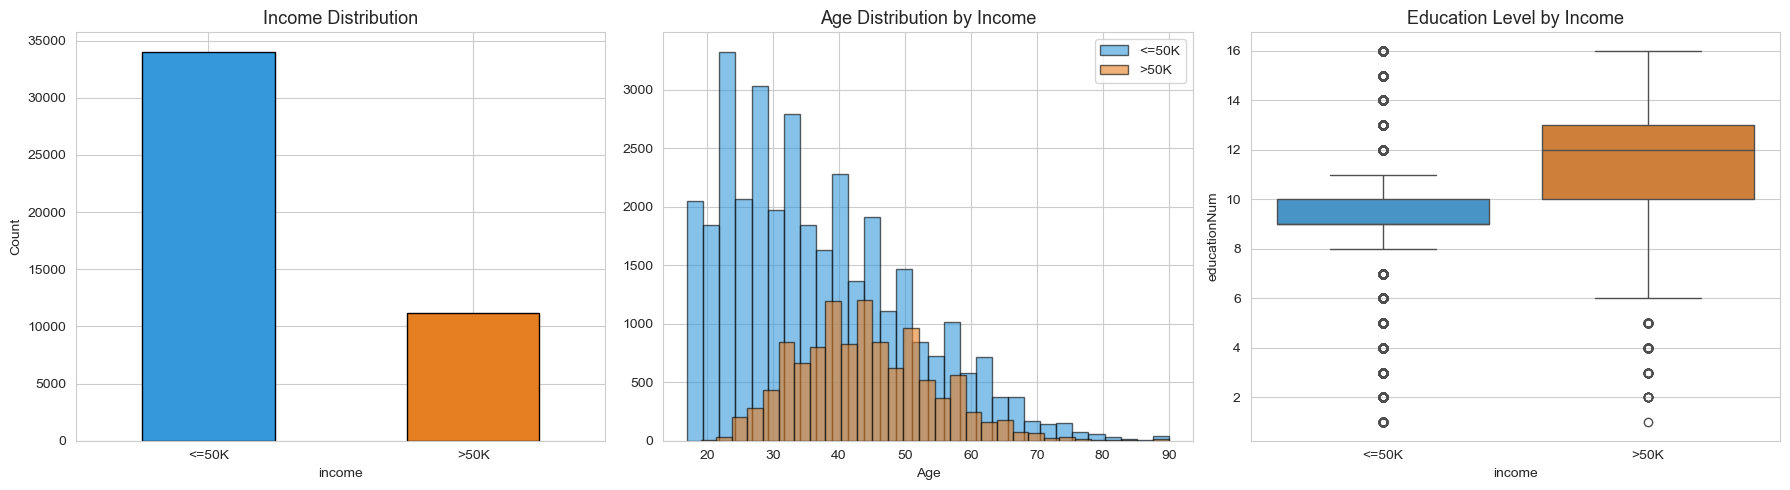

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

census['income'].value_counts().plot.bar(
    ax=axes[0], color=['#3498db', '#e67e22'], edgecolor='black')
axes[0].set_title('Income Distribution', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

for val, color in [('<=50K', '#3498db'), ('>50K', '#e67e22')]:
    subset = census[census['income'] == val]
    axes[1].hist(subset['age'].astype(int), bins=30, alpha=0.6,
                 color=color, label=val, edgecolor='black')
axes[1].set_title('Age Distribution by Income', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].legend()

sns.boxplot(data=census, x='income', y=census['educationNum'].astype(float),
            ax=axes[2], palette=['#3498db', '#e67e22'])
axes[2].set_title('Education Level by Income', fontsize=13)

plt.tight_layout()
plt.show()

The income distribution is **imbalanced** — roughly 75% earn ≤$50K and 25% earn >$50K.
This reflects the 1994 US income distribution. Key observations:

- **Age**: Higher earners skew older (peak around 35–55), while lower earners include more
  young adults entering the workforce.
- **Education**: Clear separation — the median `educationNum` for >$50K is ~13 (Bachelor's),
  compared to ~10 (some college/HS-grad) for ≤$50K. Education is one of the strongest
  individual predictors of income.

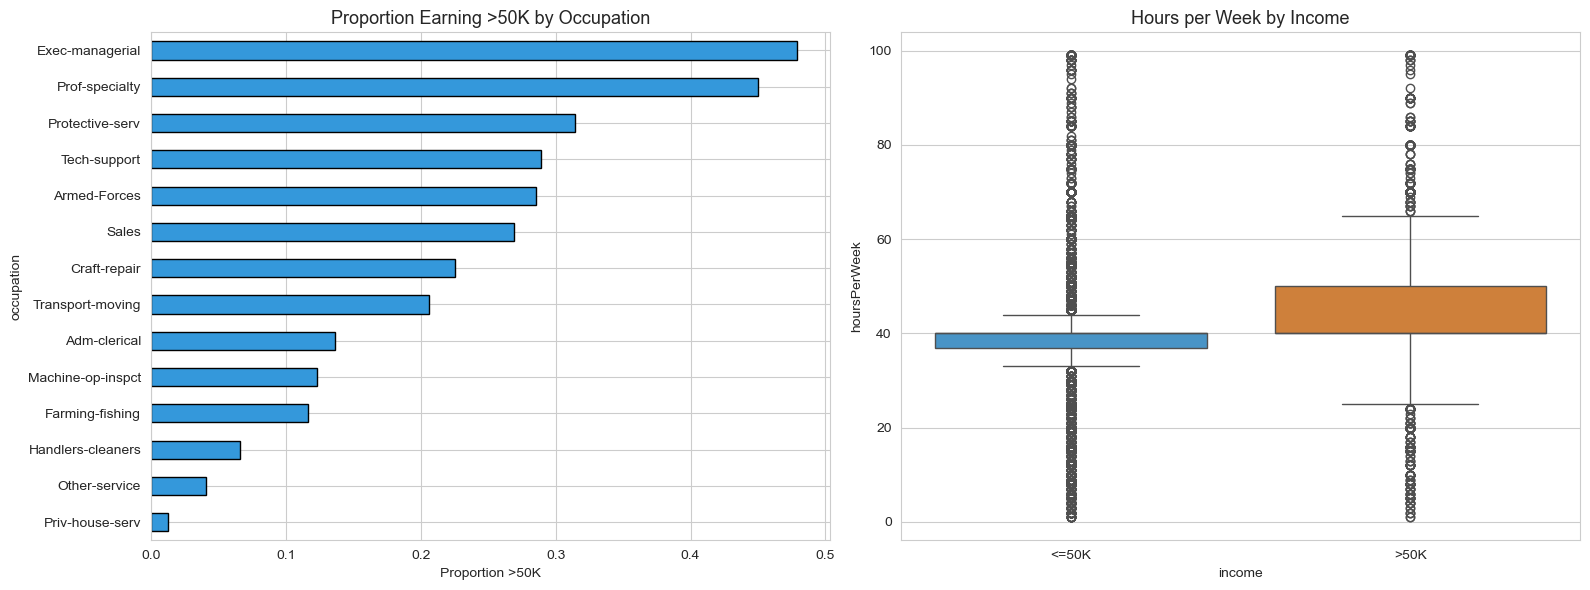

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

occ_income = census.groupby('occupation')['income'].apply(
    lambda x: (x == '>50K').mean()).sort_values()
occ_income.plot.barh(ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Proportion Earning >50K by Occupation', fontsize=13)
axes[0].set_xlabel('Proportion >50K')

sns.boxplot(data=census, x='income', y=census['hoursPerWeek'].astype(float),
            ax=axes[1], palette=['#3498db', '#e67e22'])
axes[1].set_title('Hours per Week by Income', fontsize=13)

plt.tight_layout()
plt.show()

**Occupation** is a strong income signal. Executive/managerial and professional specialty roles
have >45% earning >$50K, while service-sector and manual labor roles are below 10%.
**Hours per week** also shows a clear shift — higher earners tend to work more hours,
with a median around 45 vs. 40 for lower earners.

### 3.2 Spark Results — Model Comparison

Three classifiers trained on the same preprocessed features (`StringIndexer` → `OneHotEncoder` →
`VectorAssembler`), evaluated on a 20% held-out test set.

> **Note on metrics:** Precision, Recall, and F1 are **weighted** averages across both classes
> (≤$50K and >$50K), which accounts for the class imbalance. AUC-ROC is computed via
> `BinaryClassificationEvaluator` and measures the model's ability to rank positive
> instances higher than negative ones, independent of the classification threshold.

In [40]:
# Logistic Regression results
lr_metrics = pd.read_csv(os.path.join(RESULTS_DIR, 'part3', 'model_evaluation_metrics.csv'))
lr_metrics = lr_metrics.set_index('metric')['value']

# RF and DT results
tree_metrics = pd.read_csv(os.path.join(RESULTS_DIR, 'part4.csv'))
rf_metrics = tree_metrics[tree_metrics['classifier'] == 'RF'].set_index('metric')['value']
dt_metrics = tree_metrics[tree_metrics['classifier'] == 'DT'].set_index('metric')['value']

# Build comparison table
comparison = pd.DataFrame({
    'Logistic Regression': {
        'Accuracy': lr_metrics['Accuracy'],
        'Precision': lr_metrics['Precision'],
        'Recall': lr_metrics['Recall'],
        'F1 Score': lr_metrics['F1 Score'],
        'AUC-ROC': lr_metrics['ROC-AUC'],
    },
    'Random Forest': {
        'Accuracy': rf_metrics['Accuracy'],
        'Precision': rf_metrics['Weightedprecision'],
        'Recall': rf_metrics['Weightedrecall'],
        'F1 Score': rf_metrics['F1'],
        'AUC-ROC': rf_metrics['Roc_auc'],
    },
    'Decision Tree': {
        'Accuracy': dt_metrics['Accuracy'],
        'Precision': dt_metrics['Weightedprecision'],
        'Recall': dt_metrics['Weightedrecall'],
        'F1 Score': dt_metrics['F1'],
        'AUC-ROC': dt_metrics['Roc_auc'],
    },
})

comparison.style.format('{:.4f}').highlight_max(axis=1, props='background-color: #d4edda')

,Logistic Regression,Random Forest,Decision Tree
Accuracy,0.8138,0.8051,0.8107
Precision,0.8058,0.8008,0.8002
Recall,0.8138,0.8051,0.8107
F1 Score,0.7896,0.7719,0.7877
AUC-ROC,0.8731,0.8623,0.6977


**Model Comparison Analysis:**

- **Logistic Regression** achieves the best overall performance — highest AUC-ROC (0.8731),
  F1 (0.7896), and precision (0.8058). The 3-fold cross-validation selected `regParam=0.2`
  as optimal, applying moderate L2 regularization to prevent overfitting on the 79 encoded features.

- **Random Forest** (100 trees) slightly underperforms logistic regression across all metrics.
  This is common on tabular datasets with mostly categorical features — tree ensembles can
  overfit to high-cardinality one-hot encoded features. Its AUC-ROC of 0.8623 indicates
  good ranking ability, close to LR.

- **Decision Tree** has the most interesting result: its **accuracy (0.8107) is competitive**
  with the other models, but its **AUC-ROC (0.6977) is dramatically worse**. This reveals
  that the decision tree makes hard, confident splits rather than producing well-calibrated
  probabilities. It gets many predictions right, but when it's wrong, its confidence scores
  don't reliably indicate uncertainty. This makes it unsuitable for tasks requiring
  probability-based ranking (e.g., "flag the top 10% highest-risk individuals").

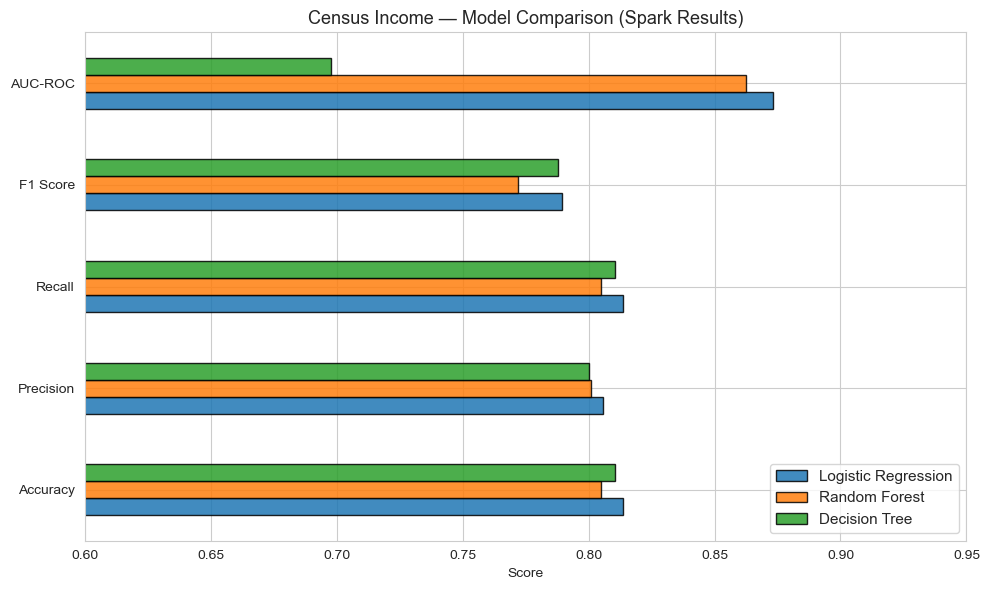

In [41]:
# Visual comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison.plot.barh(ax=ax, edgecolor='black', alpha=0.85)
ax.set_title('Census Income — Model Comparison (Spark Results)', fontsize=13)
ax.set_xlabel('Score')
ax.set_xlim(0.6, 0.95)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 3.3 Logistic Regression — Top Feature Coefficients

The Spark LR model's coefficients reveal which features most influence the income prediction.
Feature names with `_vec_N` suffixes are **one-hot encoded** categories — each represents
a specific category value from the `StringIndexer` ordering (by frequency).

For example, `occupation_vec_0` is the most frequent occupation category ("Prof-specialty"),
`relationship_vec_1` is the second most frequent relationship value ("Wife"), etc. The
`StringIndexer` assigns index 0 to the most common category, index 1 to the next, and so on.

Showing the 15 largest (positive and negative) coefficients:

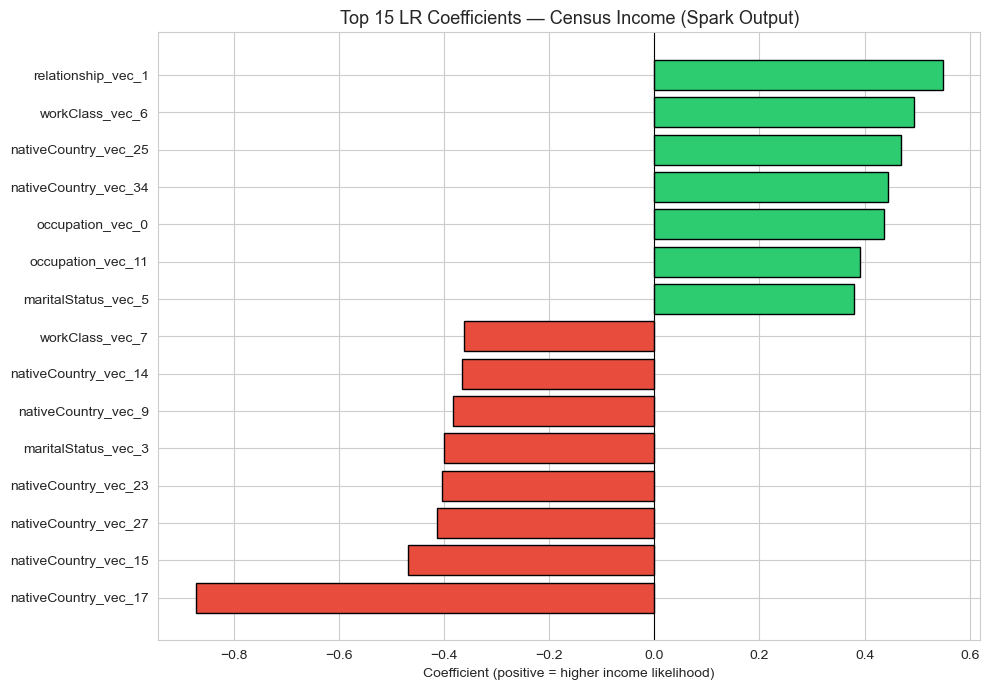

Intercept: -3.8233


In [42]:
coefs = pd.read_csv(os.path.join(RESULTS_DIR, 'part3', 'model_coefficients.csv'))
coefs_features = coefs[coefs['feature'] != 'intercept'].copy()

# Top 15 by absolute value
top15 = coefs_features.reindex(
    coefs_features['coefficient'].abs().sort_values(ascending=False).head(15).index
).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top15['coefficient']]
ax.barh(top15['feature'], top15['coefficient'], color=colors, edgecolor='black')
ax.set_title('Top 15 LR Coefficients — Census Income (Spark Output)', fontsize=13)
ax.set_xlabel('Coefficient (positive = higher income likelihood)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f'Intercept: {coefs[coefs["feature"] == "intercept"]["coefficient"].values[0]:.4f}')

**Key coefficient observations:**

- **`relationship_vec_1`** (+0.548) is the strongest positive predictor — this corresponds to
  the "Wife" relationship category, which strongly correlates with dual-income married households.
- **`workClass_vec_6`** (+0.495) and **`nativeCountry_vec_25`** (+0.470) are high positive
  coefficients for specific work class and country categories.
- **`occupation_vec_0`** (+0.437) — the most frequent occupation category (likely professional/specialty
  roles), consistent with the EDA showing >45% of these roles earning >$50K.
- **`nativeCountry_vec_17`** (-0.872) is the strongest negative coefficient overall — a specific
  country of origin associated with lower income likelihood.
- **`educationNum`** (+0.110) — each additional year of education increases the log-odds of
  earning >$50K by 0.11, confirming education as a key predictor.
- **`hoursPerWeek`** (+0.012) and **`age`** (+0.011) — positive but small per-unit effects,
  which compound over the wide ranges of these features (e.g., 20–60 hours/week).
- The **intercept** is -3.823, reflecting the base log-odds when all features are zero
  (the baseline ≤$50K class prevalence of ~75%).

---
## Summary & Key Takeaways

**All results were produced by PySpark ML pipelines running on a 3-node Spark/HDFS cluster.**
This notebook visualizes the actual Spark outputs stored in `results/` — no models were re-trained here.

### Heart Disease Prediction — Logistic Regression

| Metric | Value |
|--------|-------|
| AUC-ROC | 0.8931 |
| Precision | 0.8195 |
| Recall | 0.8934 |
| F1 Score | 0.8549 |

The model achieves strong clinical performance with 89% recall — only 13 out of 122 disease cases
were missed. The top risk factors align with established cardiology literature: **chest pain type** (`cp`),
**ST segment slope** (`slope`), and **resting ECG** (`restecg`) are the strongest positive predictors.

### Census Income — Model Comparison

| Model | Accuracy | Precision | Recall | F1 | AUC-ROC |
|-------|----------|-----------|--------|----|---------|
| Logistic Regression | 0.8138 | 0.8058 | 0.8138 | 0.7896 | **0.8731** |
| Random Forest (100 trees) | 0.8051 | 0.8008 | 0.8051 | 0.7719 | 0.8623 |
| Decision Tree | **0.8107** | 0.8002 | 0.8107 | 0.7877 | 0.6977 |

**Logistic regression wins** on the metric that matters most for ranking (AUC-ROC = 0.8731).
The decision tree's competitive accuracy (0.81) but poor AUC-ROC (0.70) illustrates a critical
ML concept: **accuracy alone is insufficient** — a model can get most predictions right while
being poorly calibrated and unreliable for probability-based decisions.

Cross-validation (3-fold, over `regParam=[0.01, 0.1, 0.2]`) selected moderate regularization
(0.2), helping the LR model generalize despite 79 one-hot encoded features.

### Toxic Comment Classification

TF-IDF (10,000 features) + independent logistic regression per label. The model produces
calibrated probability scores across all six toxicity categories. The dataset's extreme class
imbalance (~90% clean comments) is reflected in the right-skewed probability distributions —
most comments receive very low toxicity scores across all labels.

### Distributed Computing Considerations

All three projects leverage Spark's distributed computing capabilities:
- **Data parallelism** — datasets are partitioned across cluster nodes for parallel preprocessing
- **Pipeline API** — ensures reproducible, leak-free feature engineering
- **Scalability** — the same code runs on a laptop (standalone mode) or a multi-node HDFS cluster
  by simply changing the data path from `data/` to `hdfs://`

---
*End of notebook. Source code and shell scripts for the Spark pipelines are in `src/` and `scripts/`.*